In [1]:
using Pkg
Pkg.activate(".")
using Plots
using Unitful
using SolidStateDetectors
T = Float64;

  Activating project at `~/Phd/ChargeTrappingModel_dev/SSD_code`


In [7]:

using JSON
using SpecialFunctions

In [8]:
pathof(SolidStateDetectors)

"/home/ritaferi/Phd/ChargeTrappingModel_dev/SSD_code/SolidStateDetectors_local_version/src/SolidStateDetectors.jl"

In [9]:
# the geometry parameters of the model for following displaydet_rin = 1u"mm"
det_z = det_r = 10u"mm"
z_draw = det_z / 2
# CHANGE THIS WITH THE SPECIFIC VALUE FOR EACH DETECTOR
pn_r = 8.957282u"mm" # this one was calculated by searching the zero impurity point (displayed in the following section)

sim = Simulation{T}(SSD_examples[:TrueCoaxial])



Simulation{Float64, Cylindrical} - Coordinate system: Cylindrical
  Environment Material: Vacuum
  Detector: TrueCoaxial
  Electric potential: missing
  Charge density: missing
  Impurity scale: missing
  Fix Charge density: missing
  Dielectric distribution: missing
  Point types: missing
  Electric field: missing
  Weighting potentials: 
    Contact 1: missing
    Contact 2: missing


In [10]:
r_list = 0u"mm":0.01u"mm":det_r
imp_list = map(r -> let pt::CylindricalPoint{T} = CylindricalPoint(r, 0u"°", z_draw)
        SolidStateDetectors.get_impurity_density(sim.detector.semiconductor.impurity_density_model, pt) * 1e-6u"cm^-3"
    end, r_list);


In [11]:
using SolidStateDetectors: Electron, Hole
cdm = sim.detector.semiconductor.charge_drift_model
depth_list = 0u"mm":0.01u"mm":(det_r-pn_r)
mobility_list = map(depth -> let pt::CartesianPoint{T} = CartesianPoint(det_r - depth, 0, z_draw)
        (µe=SolidStateDetectors.calculate_mobility(cdm, pt, Electron) * 10000u"cm^2/(V*s)",
            µh=SolidStateDetectors.calculate_mobility(cdm, pt, Hole) * 10000u"cm^2/(V*s)")
    end, depth_list)

105-element Vector{@NamedTuple{μe::Quantity{Float64, 𝐈 𝐓^2 𝐌^-1, Unitful.FreeUnits{(cm^2, s^-1, V^-1), 𝐈 𝐓^2 𝐌^-1, nothing}}, μh::Quantity{Float64, 𝐈 𝐓^2 𝐌^-1, Unitful.FreeUnits{(cm^2, s^-1, V^-1), 𝐈 𝐓^2 𝐌^-1, nothing}}}}:
 (μe = 5219.164595302499 cm^2 s^-1 V^-1, μh = 3516.6459043920336 cm^2 s^-1 V^-1)
 (μe = 5338.537913119116 cm^2 s^-1 V^-1, μh = 3605.6079699641205 cm^2 s^-1 V^-1)
 (μe = 5466.080569449311 cm^2 s^-1 V^-1, μh = 3701.135885605666 cm^2 s^-1 V^-1)
 (μe = 5602.327426830415 cm^2 s^-1 V^-1, μh = 3803.7148503017333 cm^2 s^-1 V^-1)
 (μe = 5747.847363506367 cm^2 s^-1 V^-1, μh = 3913.868700154684 cm^2 s^-1 V^-1)
 (μe = 5903.244750719008 cm^2 s^-1 V^-1, μh = 4032.1630397064596 cm^2 s^-1 V^-1)
 (μe = 6069.1607854189915 cm^2 s^-1 V^-1, μh = 4159.208552196733 cm^2 s^-1 V^-1)
 (μe = 6246.274615458353 cm^2 s^-1 V^-1, μh = 4295.66447523953 cm^2 s^-1 V^-1)
 (μe = 6435.30418097214 cm^2 s^-1 V^-1, μh = 4442.24222030058 cm^2 s^-1 V^-1)
 (μe = 6637.00668042006 cm^2 s^-1 V^-1, μh = 4599.70910

In [12]:
# calcolo il potenziale elettrico nella griglia rozza di default
calculate_electric_potential!(sim, max_n_iterations = 10, grid = Grid(sim), verbose = false, depletion_handling = true)



In [13]:
g = sim.electric_potential.grid
ax1, ax2, ax3 = g.axes

bulk_tick_dis = 0.05u"mm"
dl_tick_dis = 0.01u"mm"

user_additional_ticks_ax1 = sort(vcat(ax1.interval.left*u"m":bulk_tick_dis:pn_r, pn_r:dl_tick_dis:ax1.interval.right*u"m"))
user_ax1 = typeof(ax1)(ax1.interval, SolidStateDetectors.to_internal_units.(user_additional_ticks_ax1))
user_g = typeof(g)((user_ax1, ax2, ax3))


Grid{Float64, 3, Cylindrical}(0.0 .. 0.01001 - length = 286, 0.0 .. 0.0 - length = 1, -1.0e-5 .. 0.01001 - length = 16)

In [14]:
calculate_electric_potential!(sim, refinement_limits = 0.1, grid = user_g, depletion_handling = true)
calculate_electric_field!(sim)
calculate_weighting_potential!(sim, 1, depletion_handling = true)
calculate_weighting_potential!(sim, 2, depletion_handling = true);

Simulation: TrueCoaxial
Electric Potential Calculation
Bias voltage: 500.0 V
φ symmetry: Detector is φ-symmetric -> 2D computation.
Precision: Float64
Device: CPU
Max. CPU Threads: 1
Coordinate system: Cylindrical
N Refinements: -> 1
Convergence limit: 1.0e-7  => 5.0e-5 V
Initial grid size: (286, 1, 16)

Grid size: (286, 1, 16) - using 1 threads now


┌ Info: 	In electric field calculation: Keyword `n_points_in_φ` not set.
│ 		Default is `n_points_in_φ = 36`. 2D field will be extended to 36 points in φ.
└ @ SolidStateDetectors /home/ritaferi/Phd/ChargeTrappingModel_dev/SSD_code/SolidStateDetectors_local_version/src/Simulation/Simulation.jl:1220


Simulation: TrueCoaxial
Weighting Potential Calculation - ID: 1
φ symmetry: Detector is φ-symmetric -> 2D computation.
Precision: Float64
Device: CPU
Max. CPU Threads: 1
Coordinate system: Cylindrical
N Refinements: -> 3
Convergence limit: 1.0e-7 
Initial grid size: (12, 1, 16)

Grid size: (16, 1, 16) - using 1 threads now
Grid size: (24, 1, 16) - using 1 threads now
Grid size: (38, 1, 16) - using 1 threads now
Simulation: TrueCoaxial
Weighting Potential Calculation - ID: 2
φ symmetry: Detector is φ-symmetric -> 2D computation.
Precision: Float64
Device: CPU
Max. CPU Threads: 1
Coordinate system: Cylindrical
N Refinements: -> 3
Convergence limit: 1.0e-7 
Initial grid size: (12, 1, 16)

Grid size: (16, 1, 16) - using 1 threads now
Grid size: (24, 1, 16) - using 1 threads now
Grid size: (38, 1, 16) - using 1 threads now


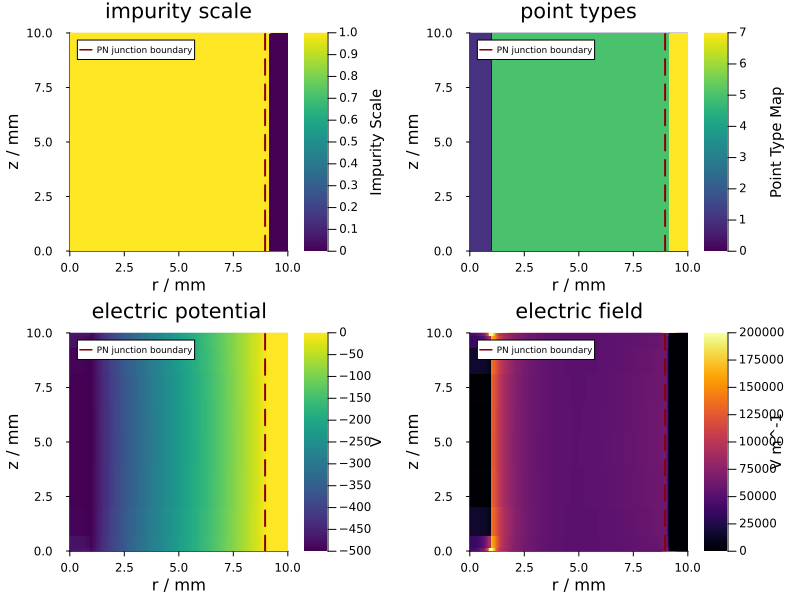

In [15]:
plot(
    begin
        imp = plot(sim.imp_scale, φ = 0, xunit = u"mm", yunit = u"mm", title = "impurity scale")
        vline!([pn_r], lw = 2, ls = :dash, color = :darkred, label = "PN junction boundary", legendfontsize = 6)
    end,
    begin
        plot(sim.point_types, φ = 0, xunit = u"mm", yunit = u"mm", title = "point types")
        vline!([pn_r], lw = 2, ls = :dash, color = :darkred, label = "PN junction boundary", legendfontsize = 6)
    end,
    begin
        plot(sim.electric_potential, xunit = u"mm", yunit = u"mm", title = "electric potential")
        vline!([pn_r], lw = 2, ls = :dash, color = :darkred, label = "PN junction boundary", legendfontsize = 6)
    end,
    begin
        plot(sim.electric_field, xunit = u"mm", yunit = u"mm", title = "electric field", clims = (0, 100*2000))
        vline!([pn_r], lw = 2, ls = :dash, color = :darkred, label = "PN junction boundary", legendfontsize = 6)
    end,
    size = (800, 600), layout = (2, 2),
)

## Pulse Shape and CCE

In [12]:
depth_list = 0.1u"mm":0.1u"mm":(det_r-pn_r)
totTime = 5u"µs"
totEnergy = 1u"keV" # --> simulating ~339 carrier pairs
N = Int(totEnergy÷2.95u"eV")  # 2.95 keV is the average energy needed to create an electron-hole pair in germanium


338

In [13]:
fieldnames(typeof(sim.detector.semiconductor.charge_trapping_model.inactive_charge_trapping_model.τh))

()

# vecchio modello
old_model = sim.detector.semiconductor.charge_trapping_model.inactive_charge_trapping_model
# nuovo modello con τh modificato
new_model = ConstantLifetimeChargeTrappingModel(0.8e-6, old_model.τe)


In [14]:
250*2.95u"eV"

737.5 eV

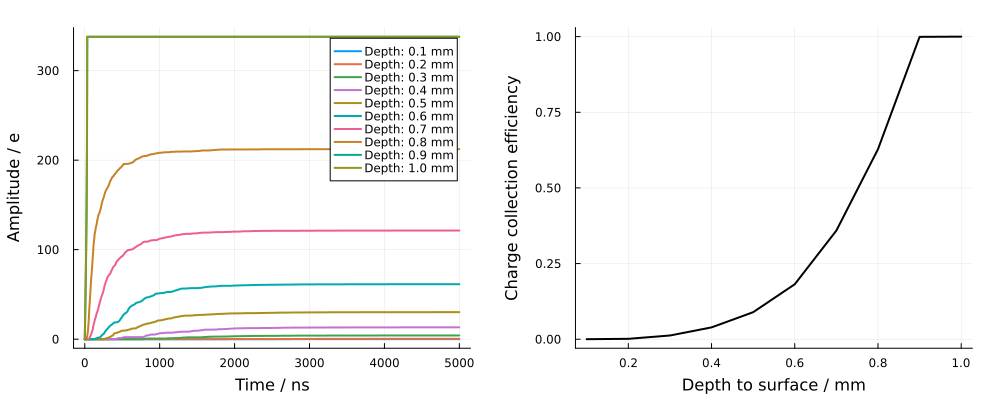

In [15]:

pulse_plot = plot()
eff_list_costtau = map(depth -> begin
        r = det_r - depth
        energy_depos = fill(2.95u"eV", N)
        starting_positions = repeat([CartesianPoint(r, 0, z_draw)], N)
        evt = Event(starting_positions, energy_depos)
        simulate!(evt, sim, Δt=1u"ns", max_nsteps=round(Int, totTime / 1u"ns"), diffusion=true, end_drift_when_no_field=false, self_repulsion=false)
        pulse = evt.waveforms[1]
        plot!(pulse_plot, pulse, label="Depth: $(round(typeof(depth), depth, digits = 1))", lw=2, yunit=u"eV/V")
        maximum(pulse.signal) / N
    end, depth_list)
plot!(pulse_plot, legend=:topright, xlabel="Time / ns", ylabel="Amplitude / e", unitformat=:nounit)
cce_plot = plot(depth_list, eff_list_costtau, xlabel="Depth to surface / mm", ylabel="Charge collection efficiency", lw=2, color=:black, label="", unitformat=:nounit)
plot(pulse_plot, cce_plot, layout=(1, 2), size=(1000, 400), margin=5Plots.mm)

# new tau(x)

In [17]:
mobility_list = map(depth -> let pt::CartesianPoint{T} = CartesianPoint(det_r - depth, 0, z_draw)
        (µe=SolidStateDetectors.calculate_mobility(cdm, pt, Electron) * 10000u"cm^2/(V*s)",
            µh=SolidStateDetectors.calculate_mobility(cdm, pt, Hole) * 10000u"cm^2/(V*s)")
    end, depth_list);

In [18]:
µe_list = [m.µe for m in mobility_list]   # lista delle µe
µh_list = [m.µh for m in mobility_list]   # lista delle µh

10-element Vector{Quantity{Float64, 𝐈 𝐓^2 𝐌^-1, Unitful.FreeUnits{(cm^2, s^-1, V^-1), 𝐈 𝐓^2 𝐌^-1, nothing}}}:
  4768.892147309549 cm^2 s^-1 V^-1
  7336.688321566626 cm^2 s^-1 V^-1
 12502.956685050258 cm^2 s^-1 V^-1
 21515.302576207006 cm^2 s^-1 V^-1
 32159.075649687504 cm^2 s^-1 V^-1
 38977.55654787303 cm^2 s^-1 V^-1
 41363.433087356825 cm^2 s^-1 V^-1
 41900.126554330505 cm^2 s^-1 V^-1
 41987.821690155964 cm^2 s^-1 V^-1
 41998.691291945055 cm^2 s^-1 V^-1

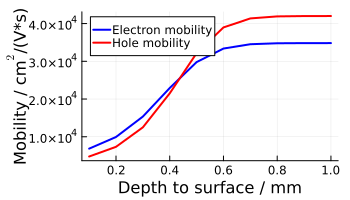

In [19]:
plot(depth_list, µe_list, label = "Electron mobility", xlabel = "Depth to surface / mm", ylabel = "Mobility / cm\$^2\$/(V*s)", lw = 2, color = :blue, unitformat = :nounit)
plot!(depth_list, µh_list, label = "Hole mobility", lw = 2, color = :red, size = (350,200))

In [20]:
fieldnames(typeof(sim.detector.semiconductor.impurity_density_model.surface_imp_model.lithium_annealing_time))

()

In [21]:
T_ann = sim.detector.semiconductor.impurity_density_model.surface_imp_model.lithium_annealing_temperature * u"K"  # K
t_ann = sim.detector.semiconductor.impurity_density_model.surface_imp_model.lithium_annealing_time * u"s"           # s


T_diff = sim.detector.semiconductor.temperature * u"K"  # temperatura del rivelatore in K
q = 1.602e-19u"C"    # carica elementare
kB = 1.380649e-23u"J/K"

1.380649e-23 J K^-1

In [22]:
Dh = µh_list .* (kB * T_diff / q)
De  = µe_list .* (kB * T_diff / q)
println("V * C / J = 1")

V_factor = (kB*T_diff/q) |> u"V"  # ora è in Volt

# Calcolo della diffusività in cm^2/s
Dh = µh_list .* V_factor  # il risultato è già in cm^2/s
De = µe_list .* V_factor

V * C / J = 1


10-element Vector{Quantity{Float64, 𝐋^2 𝐓^-1, Unitful.FreeUnits{(cm^2, s^-1), 𝐋^2 𝐓^-1, nothing}}}:
  53.14861498010066 cm^2 s^-1
  77.12856529273887 cm^2 s^-1
 119.12083497592675 cm^2 s^-1
 177.84479416652115 cm^2 s^-1
 231.0886145531054 cm^2 s^-1
 258.9140847018289 cm^2 s^-1
 267.79526054044004 cm^2 s^-1
 269.7508766873349 cm^2 s^-1
 270.07090172184303 cm^2 s^-1
 270.1107823184997 cm^2 s^-1

In [23]:
Δt = 1e-9u"s"

1.0e-9 s

In [24]:
σ_h = sqrt.(6 .* Dh .* Δt) 
σ_e = sqrt.(6 .* De .* Δt)  # diffusività moltiplicata per il tempo di annealing, poi prendo la radice quadrata

10-element Vector{Quantity{Float64, 𝐋, Unitful.FreeUnits{(cm,), 𝐋, nothing}}}:
 0.0005647049582574992 cm
 0.000680273027362127 cm
 0.0008454141055456554 cm
 0.0010329902056646651 cm
 0.0011775108013596448 cm
 0.0012463885863610007 cm
 0.0012675849333447602 cm
 0.001272204881347344 cm
 0.0012729593121270837 cm
 0.001273053295785765 cm

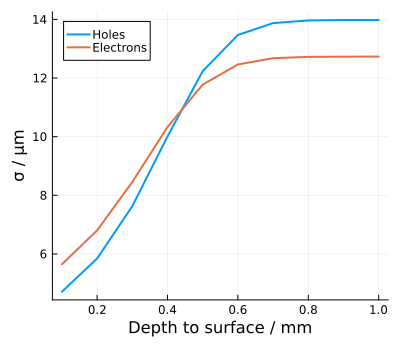

In [25]:
plot(depth_list, σ_h.*1e4, ylabel = "σ / μm", xlabel = "Depth to surface / mm", lw = 2, label = "Holes", unitformat = :nounit  )
plot!(depth_list, σ_e.*1e4, lw = 2, label = "Electrons", unitformat = :nounit , size = (400,350) )

In [26]:
T_ann

623.0 K

In [27]:
R = 1.98u"cal/(mol*K)"
H = 11800u"cal/mol"
D0 = 2.5e-3u"cm^2/s"
Ns0 = 10^(21.27)*u"cm^-3" 
Ns = Ns0*10^(-2610u"K" / T_ann)
D_Li = D0 * exp(-H / (R * T_ann))

1.7518396803995296e-7 cm^2 s^-1

In [28]:

function τ_hole(x, α)
    m0 = 9.11e-31u"kg"
    m_eff_hole = 0.21 * m0
    kB = 1.38e-23u"J/K"
    r_Li = 0.002u"cm"
    
    v_th = uconvert(u"cm/s", sqrt(3 * kB * T_diff / m_eff_hole))
    σ_trap = π * r_Li^2

    Nd_val = Ns .* erfc.(x ./ (2 * sqrt(D_Li * t_ann)))

    return 1.0 ./ (α .* Nd_val .* v_th .* σ_trap)
end

τ_hole (generic function with 1 method)

In [29]:
function τ_hole(x, α = 1.6e-11)

    # --- Constants (SI) ---
    m0 = 9.11e-31u"kg"
    m_eff_hole = 0.21 * m0
    kB = 1.38e-23u"J/K"

    # Convert radius to meters (IMPORTANT)
    r_Li = uconvert(u"m", 0.002u"cm")

    # --- Thermal velocity (m/s) ---
    v_th = sqrt(3 * kB * T_diff / m_eff_hole)

    # --- Cross section (m²) ---
    σ_trap = π * r_Li^2

    # --- Dopant concentration (force to m⁻³) ---
    Nd_val = Ns .* erfc.(x ./ (2 * sqrt(D_Li * t_ann)))
    Nd_val = uconvert.(u"m^-3", Nd_val)

    # --- Lifetime (seconds) ---
    τ = 1.0 ./ (α .* Nd_val .* v_th .* σ_trap)

    return uconvert.(u"s", τ)
end

τ_hole (generic function with 2 methods)

In [30]:
 erfc.(x ./ (2 * sqrt(D_Li * t_ann)))

UndefVarError: UndefVarError: `x` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [31]:
x = 0u"cm":0.01u"cm":0.1u"cm"
α = 1.6e-11
τh = τ_hole(x);

#plot(x.*10, τh.*1e6, label = " α = $α", xlabel = "Depth to surface / mm", ylabel = "Hole lifetime / μs", lw = 2, unitformat = :nounit)
#plot!(yscale = :log10)

11-element Vector{Quantity{Float64, 𝐓, Unitful.FreeUnits{(s,), 𝐓, nothing}}}:
 2.9602177841386505e-9 s
 4.8751939651308155e-9 s
 9.741407814936913e-9 s
 2.4063017467411876e-8 s
 7.446366736782085e-8 s
 2.9139036927405797e-7 s
 1.4515744874911024e-6 s
 9.249738550991298e-6 s
 7.566311509279891e-5 s
 0.0007966285938625378 s
 0.010817403912283103 s

In [32]:
function trapping_probability(x, Δt, α)
    if x >= x_RDR
        return 0.0        # Regione attiva: nessun trapping
    else
        τ_ns = τ_hole(x, α) * 1e9
        return 1 - exp(-Δt / τ_ns)
    end
end

trapping_probability (generic function with 1 method)

In [33]:
# vecchio modello
old_model = sim.detector.semiconductor.charge_trapping_model.inactive_charge_trapping_model
# nuovo modello con τh modificato
new_model = ConstantLifetimeChargeTrappingModel(0.8e-6, old_model.τe)


ConstantLifetimeChargeTrappingModel{Float64}(8.0e-7, 1.0e-6)

In [34]:
fieldnames(typeof(sim.detector.semiconductor.charge_trapping_model.inactive_charge_trapping_model.τh))

()

In [ ]:
depth_list = 0.01u"cm":0.001u"cm":0.1u"cm"
det_r = 1u"cm"

1 cm

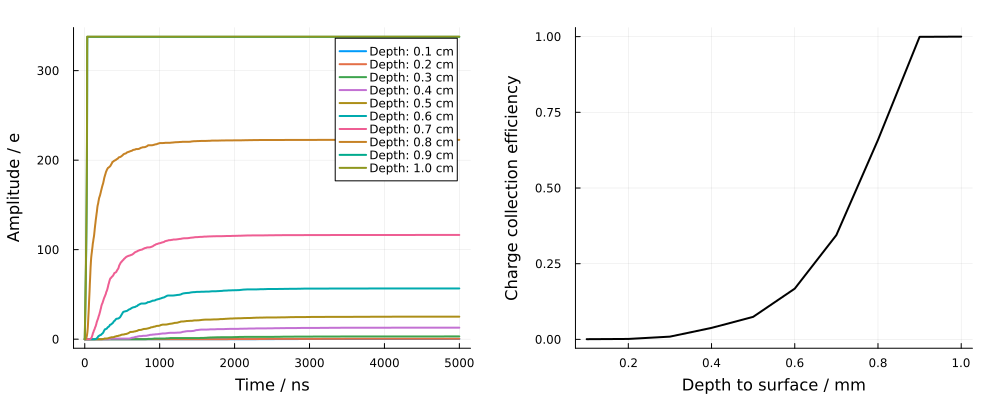

In [ ]:

pulse_plot = plot()
eff_list_taux = map(depth -> begin
        r = det_r - depth
        τh = ustrip(u"s",τ_hole(depth))
        #print(τh)
        old_model = sim.detector.semiconductor.charge_trapping_model.inactive_charge_trapping_model
        new_model = ConstantLifetimeChargeTrappingModel(τh, old_model.τh)
        energy_depos = fill(2.95u"eV", N)
        starting_positions = repeat([CartesianPoint(r, 0, z_draw)], N)
        evt = Event(starting_positions, energy_depos)
        simulate!(evt, sim, Δt=1u"ns", max_nsteps=round(Int, totTime / 1u"ns"), diffusion=true, end_drift_when_no_field=false, self_repulsion=false)
        pulse = evt.waveforms[1]
        depth = depth*10
        plot!(pulse_plot, pulse, label="Depth: $(round(typeof(depth), depth, digits = 1))", lw=2, yunit=u"eV/V")
        maximum(pulse.signal) / N
    end, depth_list)
plot!(pulse_plot, legend=:topright, xlabel="Time / ns", ylabel="Amplitude / e", unitformat=:nounit)
cce_plot_taux = plot(depth_list.*10, eff_list_taux, xlabel="Depth to surface / mm", ylabel="Charge collection efficiency", lw=2, color=:black, label="", unitformat=:nounit)
plot(pulse_plot, cce_plot_taux, layout=(1, 2), size=(1000, 400), margin=5Plots.mm)

In [53]:
τ_list = Float64[]   # array per salvare i tau
eff_list = map(depth -> begin
    τh_val =  ustrip.(u"s",τ_hole(depth))              # calcolo τ per questa profondità
    push!(τ_list,  τh_val)  # salva in τ_list

    r = det_r - depth
    old_model = sim.detector.semiconductor.charge_trapping_model.inactive_charge_trapping_model
    new_model = ConstantLifetimeChargeTrappingModel(τh_val, old_model.τe)

    energy_depos = fill(2.95u"eV", N)
    starting_positions = repeat([CartesianPoint(r, 0, z_draw)], N)
    evt = Event(starting_positions, energy_depos)
    simulate!(evt, sim, Δt=1u"ns", max_nsteps=round(Int, totTime / 1u"ns"),
              diffusion=true, end_drift_when_no_field=false, self_repulsion=false)

    pulse = evt.waveforms[1]
    plot!(pulse_plot, pulse, label="Depth: $(round(typeof(depth), depth, digits=1))", lw=2,
          yunit=u"eV/V")
    maximum(pulse.signal) / N
end, depth_list)

10-element Vector{Quantity{Float64, 𝐈 𝐓, Unitful.FreeUnits{(e,), 𝐈 𝐓, nothing}}}:
 0.00019187117068057637 e
 0.0031544700228073623 e
 0.011822239106978072 e
 0.03774392272317875 e
 0.09711943348776811 e
 0.18920204907122604 e
 0.33108177208763684 e
 0.6351519352787062 e
 0.9992517953458873 e
 0.9999569639020544 e

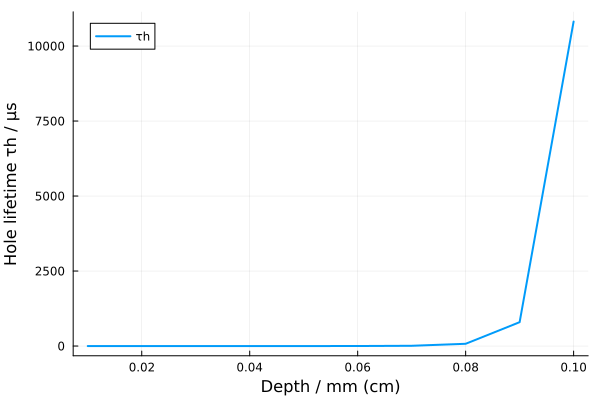

In [57]:
plot(depth_list, τ_list.*1e6, xlabel="Depth / mm", ylabel="Hole lifetime τh / μs", lw=2, label="τh")

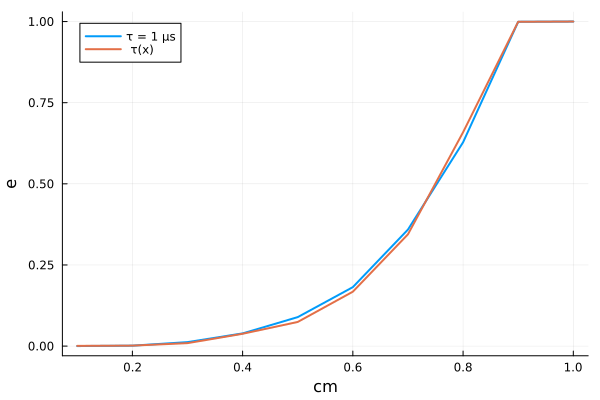

In [45]:
# confronto con risultato di Claudia

plot(depth_list.*10, eff_list_costtau, lw = 2, label = "τ = 1 μs")
plot!(depth_list.*10, eff_list_taux, lw = 2, label = " τ(x) " )